# 🧊 Átomos frios do ZERO — versão pra rodar em qualquer lugar

**Feito para o Google Colab**: roda no navegador, sem instalar nada, e
você pode mandar o link pra qualquer pessoa.

**Como usar:** aperte `Shift+Enter` em cada célula, de cima pra baixo.
Pode mexer em QUALQUER número e rodar de novo — nada quebra.

A história vai do mais simples possível e sobe um degrau por vez:

1. **Parte 1** — a pergunta, o vale, e a onda construída na mão
2. **Parte 2** — o número que resume tudo (o famoso *a*)
3. **Parte 3** — os três destinos possíveis de dois átomos
4. **Parte 4** — o degrau final: formas diferentes, mesma física

*(Pedro H. G. Modesto — mestrado IFSC/USP; laboratório completo com
orientação de Lucas Madeira, baseado no artigo RBEF 45, e20230079)*

In [1]:
# Só liga as ferramentas de desenhar. Rode e siga em frente.
import numpy as np
import matplotlib.pyplot as plt
print("Pronto! Ferramentas ligadas.")

Pronto! Ferramentas ligadas.


---
# Parte 1 — a pergunta e o vale

Dois átomos quase parados, num gás geladíssimo, se aproximam.
A pergunta do projeto INTEIRO é uma só:

> **Eles grudam ou só se esbarram e vão embora?**

Pra responder, primeiro descrevemos a "cola" entre eles com um desenho:

- **eixo horizontal** = distância entre os DOIS átomos
- **eixo vertical** = energia (zero = não se sentem; negativo = atração)

É o que os físicos chamam de *potencial*. Pensa num **vale**:

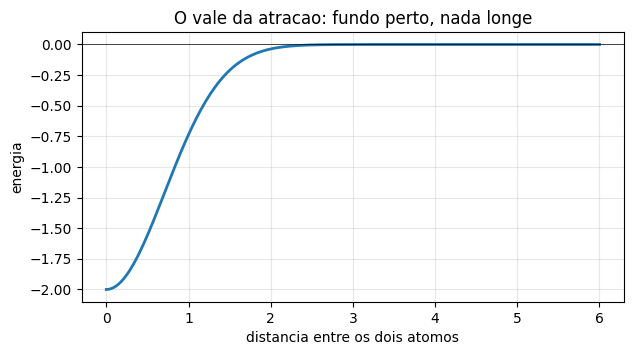

In [2]:
distancia = np.linspace(0, 6, 200)
vale = -2.0 * np.exp(-distancia**2)      # a receita do vale (só olhe o desenho)

plt.figure(figsize=(7, 3.5))
plt.plot(distancia, vale, lw=2)
plt.axhline(0, color='k', lw=0.5)
plt.xlabel("distancia entre os dois atomos")
plt.ylabel("energia")
plt.title("O vale da atracao: fundo perto, nada longe")
plt.grid(alpha=0.3)
plt.show()

**Leia o desenho:** perto (distância ~0) o gráfico afunda = atração
forte. Longe de ~3 já é zero = nem se sentem.

## A onda, construída como dominó

No mundo quântico o par de átomos é descrito por uma **onda** (vamos
chamar de `u`). A equação de Schrödinger diz só isto sobre ela:

> **dentro do vale a onda entorta; fora, segue reta.**

E o computador constrói a onda peça por peça, feito dominó: sabendo
duas peças, uma continha diz onde cai a terceira. Vamos fazer **8
passos na mão** e imprimir cada um, pra você ver que não tem mágica:

In [3]:
passo = 0.5
u_anterior = 0.0        # a onda comeca em zero no centro
u_atual = 1.0           # empurraozinho inicial (o tamanho nao importa)

print("distancia | valor da onda")
print("   0.0    |  0.000")
print("   0.5    |  1.000")
for i in range(2, 10):
    r = i * passo
    vale_aqui = -2.0 * np.exp(-r**2)
    u_proximo = 2*u_atual - u_anterior + 2*passo**2 * vale_aqui * u_atual
    print(f"   {r:.1f}    |  {u_proximo:.3f}")
    u_anterior, u_atual = u_atual, u_proximo

distancia | valor da onda
   0.0    |  0.000
   0.5    |  1.000
   1.0    |  1.632
   1.5    |  2.092
   2.0    |  2.514
   2.5    |  2.931
   3.0    |  3.347
   3.5    |  3.764
   4.0    |  4.181
   4.5    |  4.597


Cada linha nasceu das duas anteriores com UMA conta de padaria.
O computador só faz isso com 20 mil passos minúsculos. Assim:

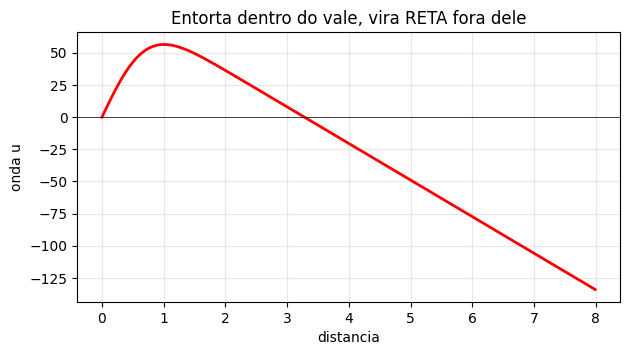

In [4]:
def constroi_onda(profundidade):
    "Constroi a onda inteira para um vale com essa profundidade."
    passo, n = 0.01, 800
    r = np.arange(n) * passo
    vale = -profundidade * np.exp(-r**2)
    u = np.zeros(n)
    u[1] = 1.0
    for i in range(1, n-1):
        u[i+1] = 2*u[i] - u[i-1] + 2*passo**2 * vale[i] * u[i]
    return r, u

r, u = constroi_onda(2.0)
plt.figure(figsize=(7, 3.5))
plt.plot(r, u, 'r-', lw=2)
plt.axhline(0, color='k', lw=0.5)
plt.xlabel("distancia"); plt.ylabel("onda u")
plt.title("Entorta dentro do vale, vira RETA fora dele")
plt.grid(alpha=0.3); plt.show()

---
# Parte 2 — o número que resume tudo

Agora o pulo do gato. Pega a parte RETA da onda (depois do vale) e
estica com uma régua. **Onde a reta cruza o chão** é um número com nome
chique — *comprimento de espalhamento* — apelido **a**. Ele responde a
pergunta lá do começo:

| onde a reta cruza | valor de a | o que significa |
|---|---|---|
| na frente | positivo | **os átomos GRUDAM** (formam molécula) |
| atrás | negativo | quase grudam, mas não |
| nunca (reta deitada) | infinito | o fio da navalha ✨ |

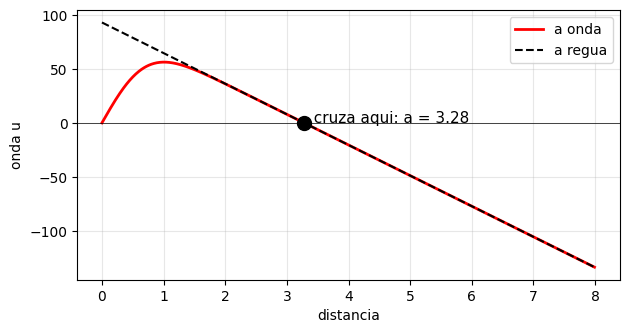

a = 3.28 -> positivo -> esses atomos GRUDAM


In [5]:
def acha_a(r, u):
    "Estica a regua na parte reta e devolve onde cruza o zero."
    x1, y1 = r[-100], u[-100]
    x2, y2 = r[-1],   u[-1]
    inclinacao = (y2 - y1) / (x2 - x1)
    return x1 - y1 / inclinacao

r, u = constroi_onda(2.0)
a = acha_a(r, u)

plt.figure(figsize=(7, 3.5))
plt.plot(r, u, 'r-', lw=2, label='a onda')
reta_x = np.linspace(0, 8, 50)
incl = (u[-1]-u[-100])/(r[-1]-r[-100])
plt.plot(reta_x, u[-100] + incl*(reta_x - r[-100]), 'k--', label='a regua')
plt.plot([a], [0], 'ko', ms=10)
plt.annotate(f'  cruza aqui: a = {a:.2f}', (a, 0), fontsize=11)
plt.axhline(0, color='k', lw=0.5)
plt.xlabel("distancia"); plt.ylabel("onda u")
plt.legend(); plt.grid(alpha=0.3); plt.show()
print(f"a = {a:.2f} -> positivo -> esses atomos GRUDAM")

---
# Parte 3 — os três destinos (mexa você!)

Troque a profundidade do vale na célula abaixo e rode de novo.
Sugestões, nesta ordem:

- `0.5` → vale raso → **a negativo** (não gruda)
- `1.34` → o ponto crítico → **a gigante** (fio da navalha)
- `3.0` → vale fundo → **a positivo** (gruda firme)

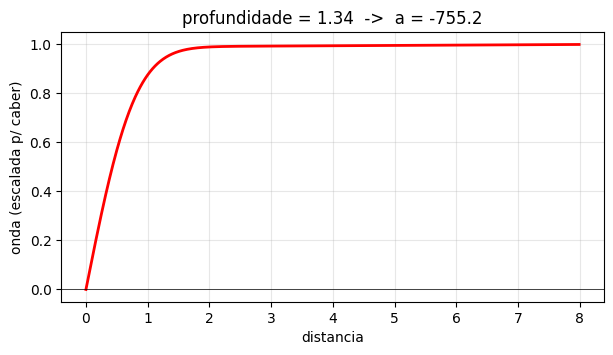

a = -755 -> GIGANTE: fio da navalha (os fisicos chamam de unitariedade)


In [6]:
profundidade = 1.34        # <<< TROQUE AQUI (0.5, 1.34, 3.0...) e rode

r, u = constroi_onda(profundidade)
a = acha_a(r, u)

plt.figure(figsize=(7, 3.5))
plt.plot(r, u/abs(u[-1]), 'r-', lw=2)
plt.axhline(0, color='k', lw=0.5)
plt.xlabel("distancia"); plt.ylabel("onda (escalada p/ caber)")
plt.title(f"profundidade = {profundidade}  ->  a = {a:.1f}")
plt.grid(alpha=0.3); plt.show()

if abs(a) > 50:
    print(f"a = {a:.0f} -> GIGANTE: fio da navalha (os fisicos chamam de unitariedade)")
elif a > 0:
    print(f"a = {a:.2f} -> gruda: forma molecula")
else:
    print(f"a = {a:.2f} -> quase gruda, mas nao")

**Por que o fio da navalha importa?** Porque nele acontecem as coisas
mais estranhas da física: três átomos formam grupinhos que dois átomos
sozinhos não conseguem (efeito Efimov) — e é ESSE o tema do mestrado
que este notebook acompanha.

---
# Parte 4 — o degrau final: formas diferentes, mesma física

Última ideia, e é a mais bonita. Vamos usar DOIS vales com formatos
completamente diferentes — um suave e um quadradão — mas calibrados
pra dar o MESMO valor de a. Olha o que acontece com as ondas longe
do vale:

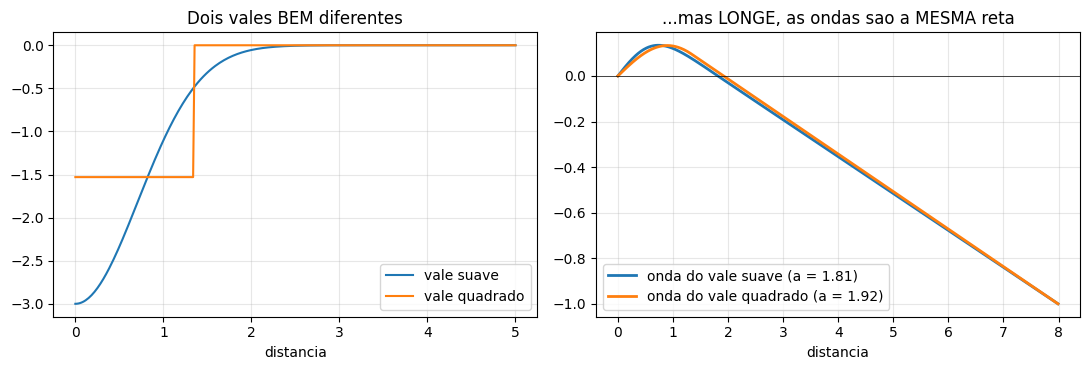

In [7]:
def constroi_onda_geral(formato_do_vale):
    passo, n = 0.01, 800
    r = np.arange(n) * passo
    u = np.zeros(n)
    u[1] = 1.0
    for i in range(1, n-1):
        u[i+1] = 2*u[i] - u[i-1] + 2*passo**2 * formato_do_vale(r[i]) * u[i]
    return r, u

vale_suave    = lambda r: -3.0 * np.exp(-r**2)              # morro suave
vale_quadrado = lambda r: -1.53 if r < 1.35 else 0.0        # degrau seco

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
rr = np.linspace(0, 5, 300)
ax[0].plot(rr, [vale_suave(x) for x in rr], label='vale suave')
ax[0].plot(rr, [vale_quadrado(x) for x in rr], label='vale quadrado')
ax[0].set_title("Dois vales BEM diferentes"); ax[0].legend()
ax[0].set_xlabel("distancia"); ax[0].grid(alpha=0.3)

for nome, vale in [('suave', vale_suave), ('quadrado', vale_quadrado)]:
    r, u = constroi_onda_geral(vale)
    a = acha_a(r, u)
    ax[1].plot(r, u/abs(u[-1]), lw=2, label=f'onda do vale {nome} (a = {a:.2f})')
ax[1].set_title("...mas LONGE, as ondas sao a MESMA reta")
ax[1].axhline(0, color='k', lw=0.5); ax[1].legend()
ax[1].set_xlabel("distancia"); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

**O que você acabou de ver** tem nome: *universalidade*. De longe, a
física não enxerga a FORMA do vale — só o número **a**. Dois vales
diferentes com o mesmo a são indistinguíveis pra quem olha de fora.

É por isso que físicos nucleares (que não sabem a forma exata da força
entre nêutrons) e físicos de átomos frios (que ajustam a atração com
ímãs) usam a MESMA teoria: no fundo, só o *a* manda.

---
## Recapitulando em 5 frases

1. Dois átomos se atraem: desenhamos o **vale**.
2. A onda deles **entorta no vale e fica reta fora**.
3. A onda é construída como **dominó**: cada ponto vem dos dois anteriores.
4. A **régua** na parte reta dá o número **a**: positivo gruda, negativo
   não, gigante = fio da navalha.
5. De longe **só o a importa** — a forma do vale, não (universalidade).

O laboratório completo (4 potenciais reais, o dêuteron, o hélio, o
potássio-39, o efeito Efimov...) é só esta história com mais capricho.

*Dúvidas, erros ou curiosidade: pedrohenriquemodesto4@gmail.com*